In [3]:
import numpy as np
import gamry_parser
import glob
from pathlib import Path
import ipywidgets as widgets
from IPython.display import display
import os
import re
import io
import tempfile
from scipy.optimize import differential_evolution, minimize, least_squares
from impedance.models.circuits import CustomCircuit
from impedance.models.circuits.elements import element
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import ScalarFormatter
import impedance.models.circuits.fitting as fitting

In [4]:
TARGET_DIR = Path(r"C:\Users\Alexa\Desktop\EIS for Alexandre Cauvel\AA2024 case")

# 2. Get all files in that directory (filtered for .DTA files)
available_files = sorted([f.name for f in TARGET_DIR.glob("*.DTA") if f.is_file()])

# 3. Create the multi-selection widget
file_selector = widgets.SelectMultiple(
    options=available_files,
    value=[], # Initial empty selection
    rows=10,  # Number of visible items in the window box
    description='Files:',
    disabled=False,
    layout=widgets.Layout(width='50%')
)

print(f"Directory: {TARGET_DIR}")
display(file_selector)

Directory: C:\Users\Alexa\Desktop\EIS for Alexandre Cauvel\AA2024 case


SelectMultiple(description='Files:', layout=Layout(width='50%'), options=('7_Bare_AA2024_1.DTA', '7_Bare_AA202…

In [28]:
file_list = [TARGET_DIR / filename for filename in file_selector.value]
print(file_list)

[WindowsPath('C:/Users/Alexa/Desktop/EIS for Alexandre Cauvel/AA2024 case/Vasco_LNV3_5.DTA')]


In [29]:
def load_gamry_safe(filename):
    # Read and trim lines after EXPERIMENTABORTED or FRACURVE
    clean_lines = []
    with open(filename, 'r', encoding='latin1') as f:
        for line in f:
            if line.strip().startswith(('EXPERIMENTABORTED', 'FRACURVE')):
                break
            clean_lines.append(line)
            
    # Write to a temporary file for GamryParser to read cleanly
    with tempfile.NamedTemporaryFile(mode='w', suffix='.dta', delete=False, encoding='latin1') as tmp:
        tmp.writelines(clean_lines)
        tmp_path = tmp.name

    parser = gamry_parser.GamryParser()
    parser.load(tmp_path)
    return parser

In [30]:
all_datasets = []

for filename in file_list:
    parser = load_gamry_safe(filename)
    data = parser.curves[0]
    header_data = parser.get_header()
    original_eis_data = {
        'name': filename.stem,
        'Zreal':data['Zreal'].values*header_data.get('AREA'),
        'Zimag':-data['Zimag'].values*header_data.get('AREA'),
        'Z_data':data['Zreal'].values*header_data.get('AREA') + 1j*data['Zimag'].values*header_data.get('AREA'),
        'Zmod':data['Zmod'].values*header_data.get('AREA'),
        'Zphz':data['Zphz'].values,
        'Freq':data['Freq'].values,
        'area':header_data.get('AREA'),
        'circuit':None,
        'Z_fit':None,
        'chi_sq': None,
        'param_errors': None
    }

    eis_data = {
        'name': filename.stem,
        'Zreal':None,
        'Zimag':None,
        'Zmod':None,
        'Zphz':None,
        'Z_data':None,
        'Freq':None,
        'circuit':None,
        'Z_fit':None,
        'chi_sq':None,
        'param_errors': None
    }
    
    all_datasets.append({"eis_data":eis_data, "original_eis_data":original_eis_data})

In [31]:
@element(num_params=2, units=['S*sec^1/2', 'sec^1/2'],overwrite = True)
def PW(p, f):
    """
    Gamry's 'O' Element: Porous Bounded Warburg
    p[0] = Yo (Admittance coefficient)
    p[1] = B (Time constant parameter)
    """
    # CRITICAL FIX: Convert the incoming list into a NumPy array
    f = np.array(f)
    
    omega = 2 * np.pi * f
    Yo, B = p[0], p[1]
    
    # Calculate the square root of (j * omega)
    s_j_omega = np.sqrt(1j * omega)
    
    # Implement coth(x) using 1 / tanh(x)
    coth_term = 1 / np.tanh(B * s_j_omega)
    
    # Final impedance calculation
    Z = coth_term / (Yo * s_j_omega)
    return Z

In [32]:
circuits_data = {
    '1RC': {
        'string': 'R0-p(R1,CPE1)',
        'bounds': {
            'R0':     {'bounds': (1, 1e3),     'log': True},
            'R1':     {'bounds': (1, 1e8),     'log': True},
            'CPE1_0': {'bounds': (1e-9, 1e-3), 'log': True},
            'CPE1_1': {'bounds': (0.5, 1.0),   'log': False},
        }
    },
    '2RC': {
        'string': 'R0-p(R1-p(R2,CPE2),CPE1)',
        'bounds': {
            'R0':     {'bounds': (1, 1e3),     'log': True},
            'R1':     {'bounds': (1, 1e8),     'log': True},
            'R2':     {'bounds': (1, 1e12),     'log': True},
            'CPE2_0': {'bounds': (1e-9, 1e-2), 'log': True},
            'CPE2_1': {'bounds': (0.5, 1.0),   'log': False},
            'CPE1_0': {'bounds': (1e-9, 1e-3), 'log': True},
            'CPE1_1': {'bounds': (0.5, 1.0),   'log': False},
        }
    },
    '1RC-PW': {
        'string': 'R0-p(R1-PW1,CPE1)',
        'bounds': {
            'R0':     {'bounds': (1, 1e3),     'log': True},
            'R1':     {'bounds': (1, 1e8),     'log': True},
            'PW1_0':  {'bounds': (1e-6, 1e2),  'log': True},
            'PW1_1':  {'bounds': (1e-3, 1e2),  'log': True},
            'CPE1_0': {'bounds': (1e-9, 1e-3), 'log': True},
            'CPE1_1': {'bounds': (0.5, 1.0),   'log': False},
        }
    },
    '2RC-PW': {
        'string': 'R0-p(R1-p(R2-PW2,CPE2),CPE1)',
        'bounds': {
            'R0':     {'bounds': (1, 1e3),     'log': True},
            'R1':     {'bounds': (1, 1e8),     'log': True},
            'R2':     {'bounds': (1, 1e12),    'log': True},
            'PW2_0':  {'bounds': (1e-6, 1e-1),  'log': True},
            'PW2_1':  {'bounds': (0.1, 1e2),  'log': True},
            'CPE2_0': {'bounds': (1e-9, 1e-2), 'log': True},
            'CPE2_1': {'bounds': (0.5, 1.0),   'log': False},
            'CPE1_0': {'bounds': (1e-9, 1e-3), 'log': True},
            'CPE1_1': {'bounds': (0.5, 1.0),   'log': False},
        }
    },
    '3RC': {
        'string': 'R0-p(R1-p(R2-p(R3,CPE3),CPE2),CPE1)',
        'bounds': {
            'R0':     {'bounds': (1, 1e3),     'log': True},
            'R1':     {'bounds': (1, 1e8),     'log': True},
            'R2':     {'bounds': (1, 1e8),     'log': True},
            'R3':     {'bounds': (1, 1e8),     'log': True},
            'CPE3_0': {'bounds': (1e-9, 1e-3), 'log': True},
            'CPE3_1': {'bounds': (0.5, 1.0),   'log': False},
            'CPE2_0': {'bounds': (1e-9, 1e-2), 'log': True},
            'CPE2_1': {'bounds': (0.5, 1.0),   'log': False},
            'CPE1_0': {'bounds': (1e-9, 1e-3), 'log': True},
            'CPE1_1': {'bounds': (0.5, 1.0),   'log': False},
        }
    },
    '4RC': {
        'string': 'R0-p(R1-p(R2-p(R3-p(R4,CPE4),CPE3),CPE2),CPE1)',
        'bounds': {
            'R0':     {'bounds': (1, 1e3),     'log': True},
            'R1':     {'bounds': (1, 1e8),     'log': True},
            'R2':     {'bounds': (1, 1e8),     'log': True},
            'R3':     {'bounds': (1, 1e8),     'log': True},
            'R4':     {'bounds': (1, 1e8),     'log': True},
            'CPE4_0': {'bounds': (1e-9, 1e-3), 'log': True},
            'CPE4_1': {'bounds': (0.5, 1.0),   'log': False},
            'CPE3_0': {'bounds': (1e-9, 1e-3), 'log': True},
            'CPE3_1': {'bounds': (0.5, 1.0),   'log': False},
            'CPE2_0': {'bounds': (1e-9, 1e-2), 'log': True},
            'CPE2_1': {'bounds': (0.5, 1.0),   'log': False},
            'CPE1_0': {'bounds': (1e-9, 1e-3), 'log': True},
            'CPE1_1': {'bounds': (0.5, 1.0),   'log': False},
        }
    }
}

In [33]:
def parameter_guesser(all_datasets, choice, data_key, circuits_data, n_restarts=3):
    circuit_string = circuits_data[choice]['string']
    param_dict = circuits_data[choice]['bounds']

    # 1. Align bounds and log-indices automatically based on impedance.py's internal ordering
    dummy_circuit = CustomCircuit(circuit_string, initial_guess=[1.0] * len(param_dict))
    param_names = dummy_circuit.get_param_names()[0]

    ordered_bounds = []
    log_idx_list = []

    print(f"\n--- PARAMETER ALIGNMENT ({choice}) ---")
    for idx, name in enumerate(param_names):
        bound_info = param_dict[name]
        ordered_bounds.append(bound_info['bounds'])

        if bound_info['log']:
            log_idx_list.append(idx)

        scale_type = "LOG" if bound_info['log'] else "LINEAR"
        print(f"Index {idx}: {name:<10s} -> {bound_info['bounds']} [{scale_type}]")

    log_idx_arr = np.array(log_idx_list, dtype=int)
    print("-------------------------------------\n")

    lower_bounds, upper_bounds = zip(*ordered_bounds)
    fit_bounds = (list(lower_bounds), list(upper_bounds))

    # Build log-space bounds for DE and Nelder-Mead
    log_bounds = [
        (np.log10(low), np.log10(high)) if idx in log_idx_arr else (low, high)
        for idx, (low, high) in enumerate(ordered_bounds)
    ]

    # Reduced Chi-Square calculation (matching Gamry's Modulus Weighting)
    def calculate_chi_squared(z_d, z_f, n_params):
        dof = max(1, (2 * len(z_d)) - n_params)
        residuals = np.abs(z_d - z_f)**2 / (np.abs(z_d)**2)
        return np.sum(residuals) / dof

    # 2. Process Datasets
    for i, dataset in enumerate(all_datasets):
        freq = dataset[data_key]['Freq']
        z_data = dataset[data_key]['Z_data']
        weight_sq = np.abs(z_data)**2

        # Scalar Objective Function for DE and Nelder-Mead (Log-space)
        def objective_function(params):
            try:
                real_params = np.array(params, copy=True)
                real_params[log_idx_arr] = 10**real_params[log_idx_arr]

                circuit = CustomCircuit(circuit_string, initial_guess=real_params)
                z_fit = circuit.predict(freq)

                if np.any(np.isnan(z_fit)) or np.any(np.isinf(z_fit)):
                    return 1e15

                return np.sum(np.abs(z_data - z_fit)**2 / weight_sq)
            except Exception:
                return 1e15

        print(f"Fitting Dataset {i + 1}/{len(all_datasets)} ({choice}) across {n_restarts} independent passes...")

        best_circuit = None
        best_chi = np.inf
        best_z_fit = None
        best_nm_circuit = None
        best_nm_chi = np.inf
        best_nm_z_fit = None

        # Execute multiple independent global passes to prevent seed-trapping
        for run_idx in range(n_restarts):
            # Step A: Global Exploration (Differential Evolution)
            de_res = differential_evolution(
                objective_function,
                log_bounds,
                strategy='best1bin',
                popsize=80,
                tol=1e-3,
                mutation=(0.5, 1.0),
                recombination=0.7,
                init='latinhypercube',
                seed=None
            )

            # Extract the top 3 best individuals from the DE population
            if hasattr(de_res, 'population') and len(de_res.population) > 0:
                pop = de_res.population
                energies = getattr(de_res, 'population_energies', [objective_function(ind) for ind in pop])
                best_3_indices = np.argsort(energies)[:min(3, len(pop))]
                top_3_candidates = [pop[idx] for idx in best_3_indices]
            else:
                top_3_candidates = [de_res.x]

            pass_best_nm_chi = np.inf
            pass_best_nm_linear = None
            pass_best_nm_circuit = None
            pass_best_nm_z_fit = None

            # Step B: Run Nelder-Mead on each of the top 3 candidates
            for cand in top_3_candidates:
                nm_res = minimize(
                    objective_function,
                    x0=cand,
                    method='Nelder-Mead',
                    bounds=log_bounds,
                    options={'maxiter': 5000, 'xatol': 1e-4, 'fatol': 1e-4}
                )

                cand_linear = np.array(nm_res.x, copy=True)
                cand_linear[log_idx_arr] = 10**cand_linear[log_idx_arr]
                cand_linear = np.clip(cand_linear, lower_bounds, upper_bounds)

                c_nm = CustomCircuit(circuit_string, initial_guess=cand_linear)
                c_nm.parameters_ = cand_linear
                c_nm.conf_ = np.zeros_like(cand_linear)
                z_nm = c_nm.predict(freq)
                chi_nm = calculate_chi_squared(z_data, z_nm, len(ordered_bounds))

                # Track best NM candidate within this pass
                if chi_nm < pass_best_nm_chi:
                    pass_best_nm_chi = chi_nm
                    pass_best_nm_linear = cand_linear
                    pass_best_nm_circuit = c_nm
                    pass_best_nm_z_fit = z_nm

            # Track overall best Nelder-Mead result across all passes
            if pass_best_nm_chi < best_nm_chi:
                best_nm_chi = pass_best_nm_chi
                best_nm_circuit = pass_best_nm_circuit
                best_nm_z_fit = pass_best_nm_z_fit

            # Step C: Only pass the single winning Nelder-Mead candidate to Levenberg-Marquardt
            c_lm = CustomCircuit(circuit_string, initial_guess=pass_best_nm_linear)
            try:
                c_lm.fit(
                    freq,
                    z_data,
                    bounds=fit_bounds,
                    weight_by_modulus=True,
                    global_opt=False,
                    maxfev=10000
                )
                z_lm = c_lm.predict(freq)
                chi_lm = calculate_chi_squared(z_data, z_lm, len(ordered_bounds))
            except Exception:
                # Fallback to Simplex solution if LM hits a hard boundary
                c_lm = pass_best_nm_circuit
                z_lm = pass_best_nm_z_fit
                chi_lm = pass_best_nm_chi

            # Retain lowest Chi-Square across all restarts
            if chi_lm < best_chi:
                best_chi = chi_lm
                best_circuit = c_lm
                best_z_fit = z_lm

        # Store winning results back into dataset
        dataset[data_key]['circuit'] = best_circuit
        dataset[data_key]['Z_fit'] = best_z_fit
        dataset[data_key]['chi_sq'] = best_chi
        dataset[data_key]['param_errors'] = getattr(best_circuit, 'conf_', np.zeros(len(ordered_bounds)))
        dataset[data_key]['circuit_nm'] = best_nm_circuit
        dataset[data_key]['Z_fit_nm'] = best_nm_z_fit
        dataset[data_key]['chi_sq_nm'] = best_nm_chi

        print(f"Dataset {i + 1} Finished. Final Chi-Square: {best_chi:.4e}\n")

    return all_datasets

In [34]:
def plotter(all_datasets, data_key, choice):
    for dataset in all_datasets:
        name = dataset[data_key]['name']
        freq = dataset[data_key]['Freq']
        z_data = dataset[data_key]['Z_data']
        z_fit = dataset[data_key]['Z_fit']

        fig = plt.figure(figsize=(12, 10))
        gs = gridspec.GridSpec(2, 2, height_ratios=[1.5, 1.2], width_ratios=[1, 1])
        
        ax1 = fig.add_subplot(gs[0, :]) 
        
        ax1.plot(z_data.real, -z_data.imag, 'o', label='Experimental Data', markersize=5, alpha=0.6)
        ax1.plot(z_fit.real, -z_fit.imag, 'r-', label='10-Parameter Fit', linewidth=2)
        
        ax1.set_aspect('equal', adjustable='box')
        limit_max = max(z_data.real.max(), -z_data.imag.max())
        limit_min = min(z_data.real.min(), -z_data.imag.min())
        ax1.set_ylim(1.1*limit_min, 1.1*limit_max)
        ax1.set_xlim(1.1*limit_min, 1.1*limit_max)
        
        ax1.set_xlabel(r'Z$_{real}$ ($\Omega$/cm$^2$)', fontsize=12)
        ax1.set_ylabel(r'-Z$_{imag}$ ($\Omega$/cm$^2$)', fontsize=12)
        ax1.set_title("Nyquist Plot")
        ax1.legend()
        ax1.ticklabel_format(style='sci', axis='both',scilimits=(0,0), useMathText=True)
        ax1.grid(True, linestyle='--', alpha=0.6)
        
        ax2 = fig.add_subplot(gs[1, 0]) 
        
        ax2.loglog(freq, abs(z_data), 'o', markersize=4, alpha=0.6)
        ax2.loglog(freq, abs(z_fit), 'r-', linewidth=1.5)
        ax2.set_xlabel("Frequency (Hz)")
        ax2.set_ylabel(r'Z$_{mod}$ ($\Omega$/cm$^2$)')
        ax2.set_title("Bode Modulus")
        ax2.grid(True, which="both", linestyle='--', alpha=0.4)
        
        ax3 = fig.add_subplot(gs[1, 1]) 
        
        ax3.semilogx(freq, np.angle(z_data, deg=True), 'o', markersize=4, alpha=0.6)
        ax3.semilogx(freq, np.angle(z_fit, deg=True), 'r-', linewidth=1.5)
        ax3.set_xlabel("Frequency (Hz)")
        ax3.set_ylabel(r"Phase Angle (deg)")
        ax3.set_title("Bode Phase")
        ax3.grid(True, which="both", linestyle='--', alpha=0.4)
        
        plt.tight_layout()
        plt.savefig(f"plots_{name}_{choice}.pdf")
        plt.show()
    return None

In [25]:
choice = '4RC'

all_datasets = parameter_guesser(all_datasets, choice, 'original_eis_data', circuits_data)


--- PARAMETER ALIGNMENT (4RC) ---
Index 0: R0         -> (1, 1000.0) [LOG]
Index 1: R1         -> (1, 100000000.0) [LOG]
Index 2: R2         -> (1, 100000000.0) [LOG]
Index 3: R3         -> (1, 100000000.0) [LOG]
Index 4: R4         -> (1, 100000000.0) [LOG]
Index 5: CPE4_0     -> (1e-09, 0.001) [LOG]
Index 6: CPE4_1     -> (0.5, 1.0) [LINEAR]
Index 7: CPE3_0     -> (1e-09, 0.001) [LOG]
Index 8: CPE3_1     -> (0.5, 1.0) [LINEAR]
Index 9: CPE2_0     -> (1e-09, 0.01) [LOG]
Index 10: CPE2_1     -> (0.5, 1.0) [LINEAR]
Index 11: CPE1_0     -> (1e-09, 0.001) [LOG]
Index 12: CPE1_1     -> (0.5, 1.0) [LINEAR]
-------------------------------------

Fitting Dataset 1/3 (4RC) across 3 independent passes...


C:\pea\code\parameter_guesser\.venv\Lib\site-packages\impedance\models\circuits\circuits.py:145: UserWarning: Simulating circuit based on initial parameters
  warnings.warn("Simulating circuit based on initial parameters")


Dataset 1 Finished. Final Chi-Square: 1.2947e-04

Fitting Dataset 2/3 (4RC) across 3 independent passes...
Dataset 2 Finished. Final Chi-Square: 1.5126e-03

Fitting Dataset 3/3 (4RC) across 3 independent passes...
Dataset 3 Finished. Final Chi-Square: 9.2822e-05



In [13]:
print(all_datasets[0]['original_eis_data']['circuit'])


Circuit string: R0-p(R1-p(R2,CPE2),CPE1)
Fit: True

Initial guesses:
     R0 = 1.20e+02 [Ohm]
     R1 = 3.55e+04 [Ohm]
     R2 = 3.75e+04 [Ohm]
  CPE2_0 = 2.13e-04 [Ohm^-1 sec^a]
  CPE2_1 = 6.71e-01 []
  CPE1_0 = 2.10e-05 [Ohm^-1 sec^a]
  CPE1_1 = 9.43e-01 []

Fit parameters:
     R0 = 1.20e+02  (+/- 1.02e-01) [Ohm]
     R1 = 3.55e+04  (+/- 3.36e+02) [Ohm]
     R2 = 3.75e+04  (+/- 4.29e+03) [Ohm]
  CPE2_0 = 2.13e-04  (+/- 1.30e-05) [Ohm^-1 sec^a]
  CPE2_1 = 6.71e-01  (+/- 3.19e-02) []
  CPE1_0 = 2.10e-05  (+/- 5.39e-08) [Ohm^-1 sec^a]
  CPE1_1 = 9.43e-01  (+/- 5.62e-04) []



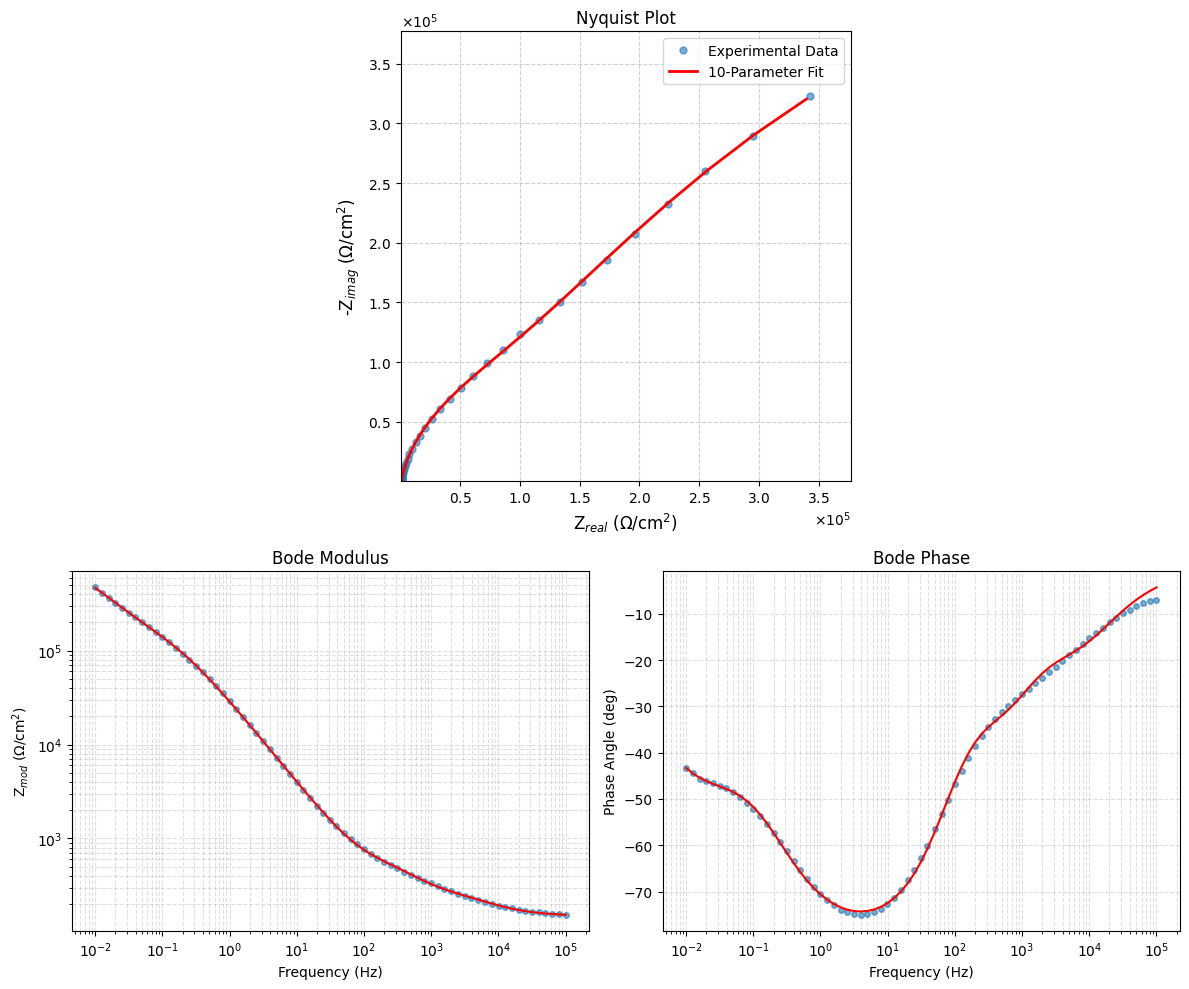

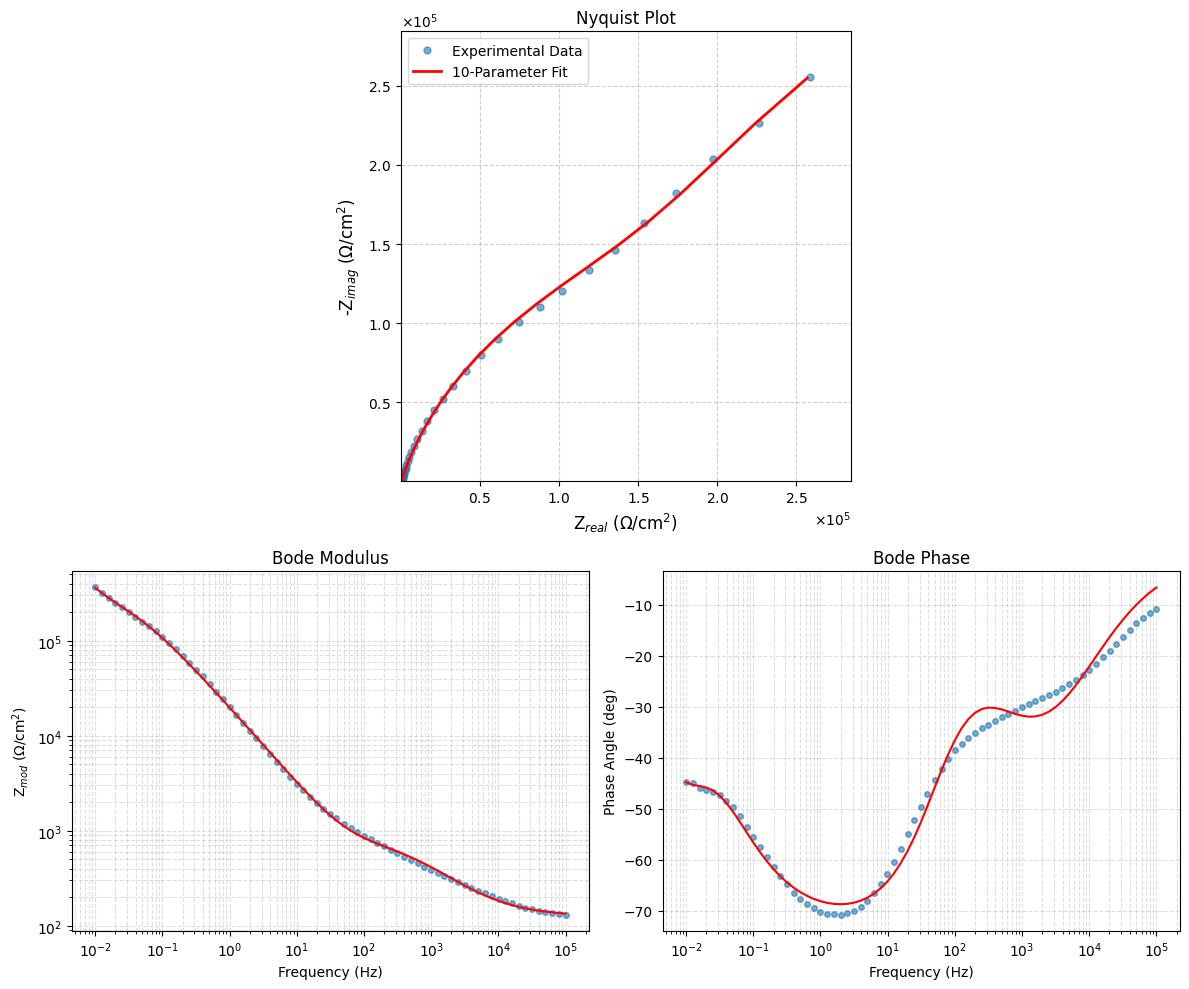

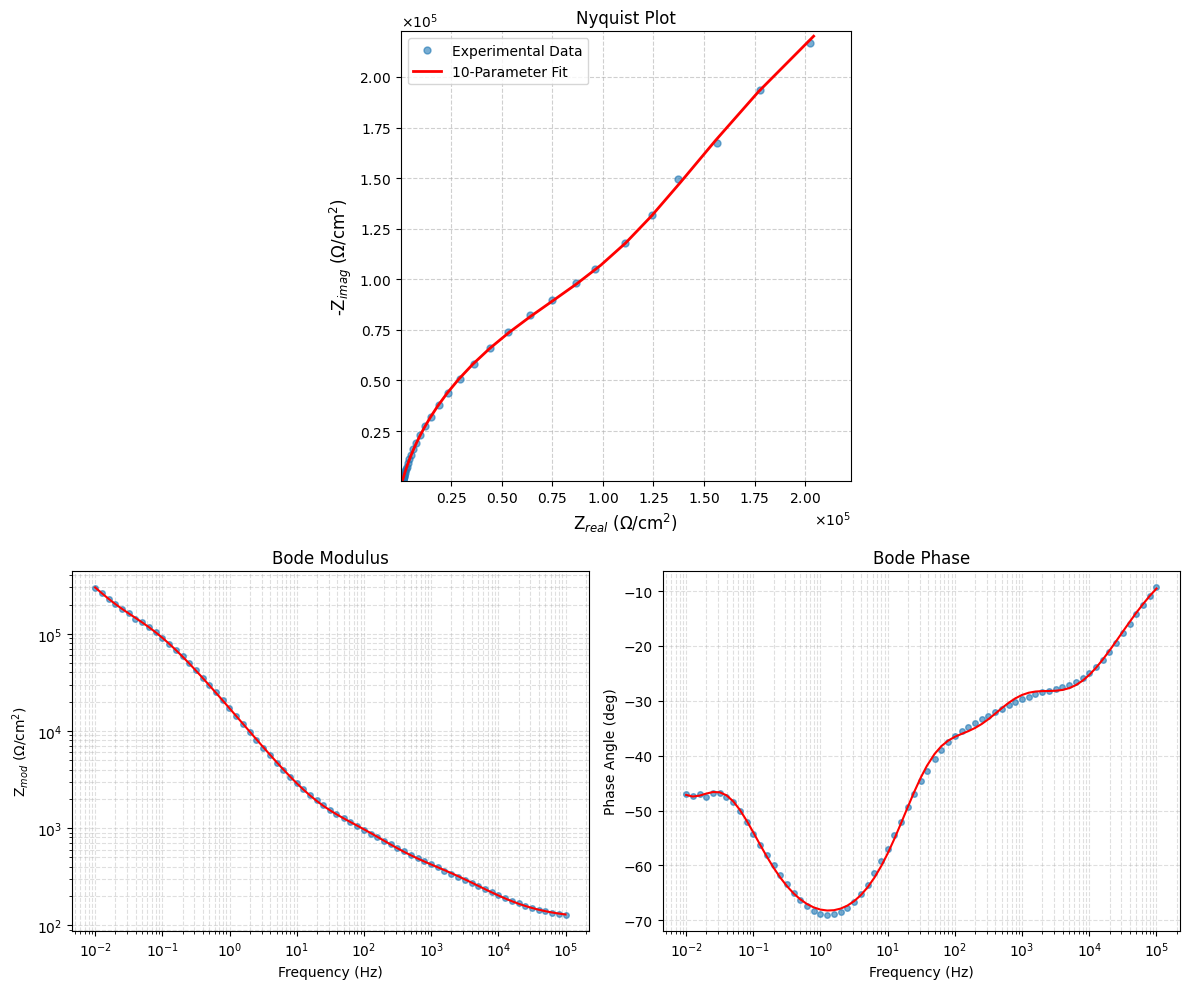

In [26]:
plotter(all_datasets, 'original_eis_data', choice)

In [48]:
end_points_to_drop = 0
freq_condition_max = 1e5
freq_condition_min = 1e-1

def data_to_keep(all_datasets,end_points_to_drop, freq_condition_max, freq_condition_min):

    for dataset in all_datasets:
        freqs = np.array(dataset['original_eis_data']['Freq'])

        combined_condition = (freqs <= freq_condition_max) & (freqs >= freq_condition_min)
        
        keys = ['Freq', 'Zreal', 'Zimag', 'Zmod', 'Zphz', 'Z_data']

        for key in keys:
            if end_points_to_drop > 0:
                dataset['eis_data'][key] = dataset['original_eis_data'][key][combined_condition]
                dataset['eis_data'][key] = dataset['eis_data'][key][:-end_points_to_drop]
            else:
                dataset['eis_data'][key] = dataset['original_eis_data'][key][combined_condition]
                
    return all_datasets

all_datasets = data_to_keep(all_datasets, end_points_to_drop, freq_condition_max, freq_condition_min)

In [49]:
choice = '3RC'

all_datasets = parameter_guesser(all_datasets, choice, 'eis_data', circuits_data)


--- PARAMETER ALIGNMENT (3RC) ---
Index 0: R0         -> (1, 1000.0) [LOG]
Index 1: R1         -> (1, 100000000.0) [LOG]
Index 2: R2         -> (1, 100000000.0) [LOG]
Index 3: R3         -> (1, 100000000.0) [LOG]
Index 4: CPE3_0     -> (1e-09, 0.001) [LOG]
Index 5: CPE3_1     -> (0.5, 1.0) [LINEAR]
Index 6: CPE2_0     -> (1e-09, 0.01) [LOG]
Index 7: CPE2_1     -> (0.5, 1.0) [LINEAR]
Index 8: CPE1_0     -> (1e-09, 0.001) [LOG]
Index 9: CPE1_1     -> (0.5, 1.0) [LINEAR]
-------------------------------------

Fitting Dataset 1/1 (3RC) across 3 independent passes...


C:\pea\code\parameter_guesser\.venv\Lib\site-packages\impedance\models\circuits\circuits.py:145: UserWarning: Simulating circuit based on initial parameters
  warnings.warn("Simulating circuit based on initial parameters")


Dataset 1 Finished. Final Chi-Square: 1.2670e-04



In [50]:
print(all_datasets[0]['eis_data']['circuit'])


Circuit string: R0-p(R1-p(R2-p(R3,CPE3),CPE2),CPE1)
Fit: True

Initial guesses:
     R0 = 1.17e+02 [Ohm]
     R1 = 4.73e+02 [Ohm]
     R2 = 2.02e+03 [Ohm]
     R3 = 4.05e+05 [Ohm]
  CPE3_0 = 2.03e-06 [Ohm^-1 sec^a]
  CPE3_1 = 1.00e+00 []
  CPE2_0 = 4.63e-06 [Ohm^-1 sec^a]
  CPE2_1 = 8.08e-01 []
  CPE1_0 = 4.87e-06 [Ohm^-1 sec^a]
  CPE1_1 = 6.82e-01 []

Fit parameters:
     R0 = 1.16e+02  (+/- 1.11e+00) [Ohm]
     R1 = 4.47e+02  (+/- 5.69e+01) [Ohm]
     R2 = 1.21e+03  (+/- 2.94e+02) [Ohm]
     R3 = 3.61e+05  (+/- 1.90e+04) [Ohm]
  CPE3_0 = 3.99e-06  (+/- 1.12e-06) [Ohm^-1 sec^a]
  CPE3_1 = 9.06e-01  (+/- 3.14e-02) []
  CPE2_0 = 2.66e-06  (+/- 1.88e-06) [Ohm^-1 sec^a]
  CPE2_1 = 8.60e-01  (+/- 8.80e-02) []
  CPE1_0 = 4.67e-06  (+/- 9.28e-07) [Ohm^-1 sec^a]
  CPE1_1 = 6.84e-01  (+/- 1.67e-02) []



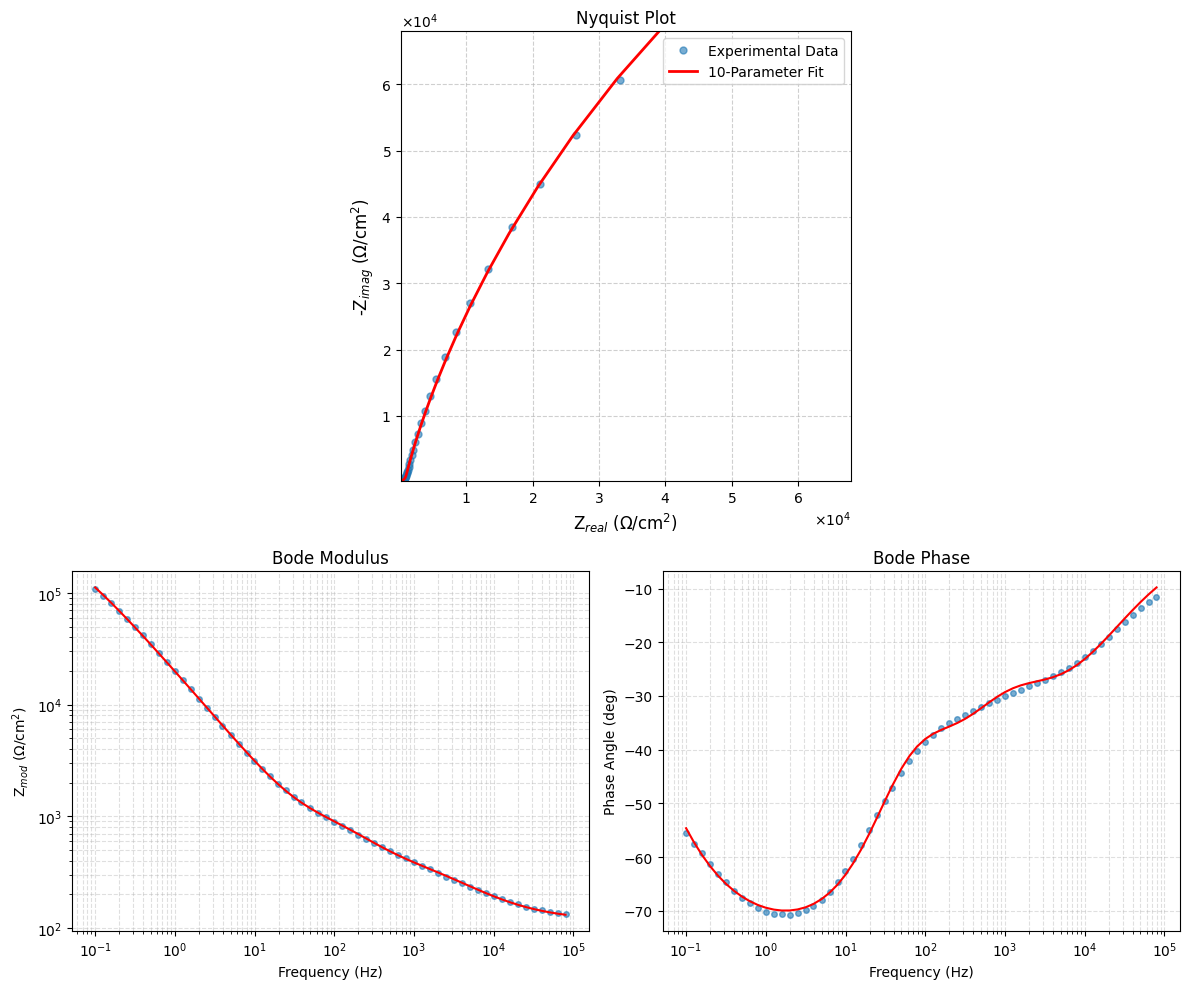

In [51]:
plotter(all_datasets, 'eis_data', choice)

In [16]:
def generate_combined_eis_report(
    all_datasets, 
    data_key, 
    circuits_data, 
    end_points_to_drop, 
    freq_condition_max, 
    freq_condition_min, 
    choice=None, 
    output_filename="eis_report.tex"
):
    # 1. Infer circuit and choice key (with whitespace normalization)
    first_circuit = all_datasets[0][data_key]['circuit']
    circuit_string = getattr(first_circuit, 'circuit', '')

    if choice is None or choice not in circuits_data:
        choice = "Unknown"
        clean_target_str = circuit_string.replace(" ", "")
        for key, data in circuits_data.items():
            if data['string'].replace(" ", "") == clean_target_str:
                choice = key
                break

    # 2. Extract parameter names and units directly from impedance.py
    try:
        param_names, param_units = first_circuit.get_param_names()
    except Exception:
        # Fallback to dictionary keys if get_param_names fails
        if choice != "Unknown":
            param_names = list(circuits_data[choice]['bounds'].keys())
            param_units = ["-"] * len(param_names)
        else:
            param_names, param_units = [], []

    # 3. Build Header with \specialcell
    header = r"\textbf{Element} & \textbf{Unit} & \textbf{Bounds}"
    column_setup = "|l|c|c|"
    for dataset in all_datasets:
        clean_file_name = dataset[data_key]['name'].replace("_", r"\_ \\ ")
        header += f" & \\textbf{{\\specialcell{{{clean_file_name}}}}}"
        column_setup += "c|"

    # 4. Build Table Rows with Dynamic Bounds
    table_rows = ""
    for idx, (p_name, p_unit) in enumerate(zip(param_names, param_units)):
        # --- Dynamic Math LaTeX Name Mapping ---
        if "CPE" in p_name:
            num = re.search(r'CPE(\d+)', p_name).group(1) if re.search(r'CPE(\d+)', p_name) else ""
            display_name = f"Q_{{{num}}}" if p_name.endswith("_0") else f"n_{{{num}}}"
        elif "PW" in p_name:
            num = re.search(r'PW(\d+)', p_name).group(1) if re.search(r'PW(\d+)', p_name) else ""
            display_name = f"Y_{{o,{num}}}" if p_name.endswith("_0") else f"B_{{{num}}}"
        elif p_name.startswith("L"):
            num = re.search(r'L(\d+)', p_name).group(1) if re.search(r'L(\d+)', p_name) else ""
            display_name = f"L_{{{num}}}"
        elif p_name[0].isdigit() and "_" in p_name: 
            p_idx, p_type = p_name.split("_")
            display_name = rf"W_{{{p_idx},R}}" if p_type == "0" else rf"W_{{{p_idx},\tau}}"
        elif p_name.startswith("R"):
            num = re.search(r'R(\d+)', p_name).group(1) if re.search(r'R(\d+)', p_name) else ""
            display_name = f"R_{{{num}}}"
        else:
            display_name = p_name

        clean_p_name = f"${display_name}$"
        
        # Format Units
        clean_unit = (
            p_unit.replace("Ohm", r"$\Omega$")
                  .replace("^-1/2", r"$^{-1/2}$")
                  .replace("^-1", r"$^{-1}$")
                  .replace("^1/2", r"$^{1/2}$")
                  .replace("^a", r"$^{a}$")
        )
        if not clean_unit.strip() or clean_unit in ["[]", "[-]"]: 
            clean_unit = "-"

        # --- Extract Dynamic Bounds from circuits_data ---
        bounds_str = "-"
        if choice in circuits_data and p_name in circuits_data[choice]['bounds']:
            b_low, b_high = circuits_data[choice]['bounds'][p_name]['bounds']
            bounds_str = f"$[{b_low:.1e}, {b_high:.1e}]$"
            
        row_content = f"{clean_p_name} & {clean_unit} & {bounds_str}"
        
        # --- Parameter Values & Standard Errors ---
        for dataset in all_datasets:
            circ = dataset[data_key]['circuit']
            if hasattr(circ, 'parameters_') and hasattr(circ, 'conf_') and circ.parameters_ is not None:
                val = circ.parameters_[idx]
                err = circ.conf_[idx] if circ.conf_ is not None and not np.isnan(circ.conf_[idx]) else 0.0
                row_content += f" & ${val:.2e} \\pm {err:.1e}$"
            else:
                row_content += " & N/A"
        
        table_rows += rf"        {row_content} \\ \hline" + "\n"

    # 5. Chi-Squared Row
    chi_row = r"\textbf{$\chi^2$} & - & - " 
    for dataset in all_datasets:
        chi = dataset[data_key]['chi_sq']
        chi_row += f" & ${chi:.3e}$"
    table_rows += rf"        {chi_row} \\ \hline" + "\n"

    # 6. Plot Sections & Multi-Page Data Tables
    plot_sections = ""
    for dataset in all_datasets:
        d_name = dataset[data_key]['name']
        clean_d_name = d_name.replace("_", r"\_")
        plot_file = f"plots_{d_name.replace('.DTA', '')}_{choice}.pdf"
        
        # Plot Page
        plot_sections += r"""
\newpage
\section*{Analysis Results: """ + clean_d_name + r"""}
\begin{center}
    \includegraphics[width=0.7\textwidth]{""" + plot_file + r"""}
    \captionof{figure}{EIS Fit Results for """ + clean_d_name + r"""}
\end{center}
"""

        # Multi-page fitted data table
        freq = dataset[data_key]['Freq']
        z_fit = dataset[data_key]['Z_fit']
        
        z_real = z_fit.real
        z_imag_neg = -z_fit.imag
        z_mod = np.abs(z_fit)
        z_phase = np.angle(z_fit, deg=True)
        
        plot_sections += r"""
\begin{landscape}
\section*{Fitted Data: """ + clean_d_name + r"""}
\begin{center}
\tiny 
\begin{longtable}{|c|c|c|c|c|}
    \hline
    \textbf{Frequency (Hz)} & \textbf{Z$_{real}$ ($\Omega$)} & \textbf{-Z$_{imag}$ ($\Omega$)} & \textbf{Z$_{mod}$ ($\Omega$)} & \textbf{Z$_{phase}$ ($^\circ$)} \\ \hline
    \endfirsthead
    
    \multicolumn{5}{c}%
    {{\bfseries \tablename\ \thetable{} -- continued from previous page}} \\
    \hline
    \textbf{Frequency (Hz)} & \textbf{Z$_{real}$ ($\Omega$)} & \textbf{-Z$_{imag}$ ($\Omega$)} & \textbf{Z$_{mod}$ ($\Omega$)} & \textbf{Z$_{phase}$ ($^\circ$)} \\ \hline
    \endhead
    
    \hline \multicolumn{5}{|r|}{{Continued on next page}} \\ \hline
    \endfoot
    
    \hline
    \endlastfoot
"""
        for f, zr, zi, zm, zp in zip(freq, z_real, z_imag_neg, z_mod, z_phase):
            plot_sections += f"    {f:.4e} & {zr:.4e} & {zi:.4e} & {zm:.4e} & {zp:.4f} \\\\\n"
        
        plot_sections += r"""\end{longtable}
\end{center}
\end{landscape}
"""

    # 7. Dataset description
    if data_key == 'original_eis_data':
        data_description = "original data"
    else:
        formatted_freq_max = f"{float(freq_condition_max):.0e}"
        formatted_freq_min = f"{float(freq_condition_min):.0e}"
        data_description = (
            f"altered data, first {end_points_to_drop} points removed and "
            f"points with $freq > {formatted_freq_max}$ and "
            f"$freq < {formatted_freq_min}$ removed"
        )

    # 8. Final LaTeX Document Assembly
    tex_final = r"""
\documentclass[10pt]{article}
\usepackage[utf8]{inputenc}
\usepackage{graphicx}
\usepackage{amsmath, amssymb}
\usepackage{geometry}
\usepackage{caption} 
\usepackage{longtable} 
\usepackage{lscape} 
\usepackage{adjustbox}
\geometry{a4paper, margin=0.5in, landscape} 

\newcommand{\specialcell}[2][c]{%
  \begin{tabular}[#1]{@{}c@{}}#2\end{tabular}}

\begin{document}

\section*{Comparative EIS Kinetics Report}
\textbf{Model Structure:} \texttt{""" + circuit_string.replace("_", r"\_") + r"""} \\
\textbf{Used data:} """ + data_description + r"""

\begin{center}
""" + f"    \\includegraphics[width=0.45\\textwidth]{{circuits/{choice}.png}}" + r"""
\end{center}

\renewcommand{\arraystretch}{1.6} 
\begin{table}[h!]
    \centering
    \begin{adjustbox}{max width=\textwidth}
    \begin{tabular}{""" + column_setup + r"""}
        \hline
        """ + header + r""" \\ \hline
""" + table_rows + r"""
    \end{tabular}
    \end{adjustbox}
\end{table}

""" + plot_sections + r"""

\end{document}
"""

    if not output_filename.endswith(".tex"):
        output_filename += ".tex"
        
    with open(output_filename, "w", encoding="utf-8") as f:
        f.write(tex_final)

In [52]:
generate_combined_eis_report(all_datasets, 
                             "eis_data", 
                             circuits_data, 
                             end_points_to_drop, 
                             freq_condition_max, 
                             freq_condition_min, 
                             choice, 
                             "AA2024_LNV3_5_highfreq_3RC_v2.3.tex")

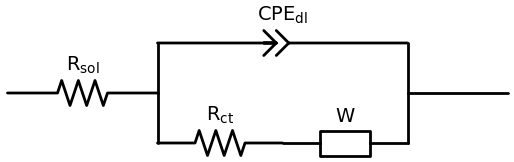

In [67]:
import schemdraw
import schemdraw.elements as elm

with schemdraw.Drawing() as d:
    d += elm.Resistor().right().label(r'$\text{R}_{\text{sol}}$')
    d.push()
    d += elm.Line().up().length(1)
    d += elm.CPE().right().length(5).label(r'$\text{CPE}_{\text{dl}}$')
    d += elm.Line().down().length(1)
    d += elm.Line().right().length(2)
    d.pop()
    d += elm.Line().down().length(1)
    d += elm.Resistor().right().length(2.5).label(r'$\text{R}_{\text{ct}}$')
    d += elm.ResistorIEC().right().length(2.5).label(r'$\text{W}$')
    d += elm.Line().up().length(1)
    d.save('1RC_W_legends.svg', dpi = 500, transparent=True)
    
    
    